给定如下两个函数,
$f(x) = \sqrt{1 - x^2}, \quad x \in [-1, 1]$,
$f(x) = \frac{1}{(1+25x^2)}, \quad x \in [-1, 1]$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f1(x):
  return np.sqrt(1 - x**2)

def f2(x):
  return 1 / (1 + 25 * x**2)

## 1


考虑它们在等距插值点 $x_0, x_1, \dots, x_n$ 上的多项式插值，其中节点为
$$
x_k = -1 + \frac{2k}{n}, \quad k = 0, 1, \dots, n. \tag{1}
$$


基于Lagrange插值方法分别编程实现 $n = 5, 10, 20, 40$ 时的插值多项式 $P(x)$, 并计算误差
$$
\max_{x \in [-1, 1]} |f(x) - P(x)| \approx \max_{0 \le j \le N} |f(\tilde{x}_j) - P(\tilde{x}_j)|, \quad \tilde{x}_j = -1 + \frac{2j}{N}.
$$

在n = 20时作出插值多项式P(x)与f(x)的对比图。此外，在不同n下以表格形式输出误差
值, 输出误差请使用科学计数法并保留三位有效数字, N=200

x轴为[-1,1], 分成200份，y轴为函数值，P(x)与f(x)都画在图上

In [2]:
# from scipy.interpolate import lagrange
# From https://github.com/scipy/scipy/blob/v1.15.2/scipy/interpolate/_interpolate.py#L0-L1
from numpy import poly1d

def lagrange(x, w):
    M = len(x)
    p = poly1d(0.0)
    for j in range(M):
        pt = poly1d(w[j])
        for k in range(M):
            if k == j:
                continue
            fac = x[j]-x[k]
            pt *= poly1d([1.0, -x[k]])/fac
        p += pt
    return p

In [3]:
def compute_interpolation(f, n, node_type='equispaced', N=200):
    if node_type == 'equispaced':
        x_nodes = np.linspace(-1, 1, n + 1)
    elif node_type == 'chebyshev':
        k = np.arange(n + 1)
        x_nodes = np.cos((2 * k + 1) * np.pi / (2 * (n + 1)))
    y_nodes = f(x_nodes)
    poly = lagrange(x_nodes, y_nodes)
    x_eval = np.linspace(-1, 1, N+1)
    y_true = f(x_eval)
    y_interp = poly(x_eval)

    error = np.max(np.abs(y_true - y_interp))
    return poly, x_eval, y_true, y_interp, error

def plot_interpolation(f, n, func_name, node_type='equispaced'):
    poly, x_eval, y_true, y_interp, _ = compute_interpolation(f, n, node_type='equispaced')

    plt.figure(figsize=(10, 6))
    plt.plot(x_eval, y_true, 'b-', label=f'f(x) = {func_name}')
    plt.plot(x_eval, y_interp, 'r--', label=f'P(x) (n={n})')
    plt.scatter(np.linspace(-1, 1, n+1), f(np.linspace(-1, 1, n+1)), c='k', label='Interpolation nodes')
    plt.title(f'Interpolation of {func_name} with n={n}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid(True)
    plt.legend()
    plt.show()
def generate_error_table(node_type='equispaced'):
    n_values = [5, 10, 20, 40]
    functions = [(f1, 'sqrt(1-x^2)'), (f2, '1/(1+25x^2)')]
    errors = {f.__name__: [] for f in [f1, f2]}

    for n in n_values:
        for f, _ in functions:
            _, _, _, _, error = compute_interpolation(f, n, node_type)
            errors[f.__name__].append(error)

    table = "| n | f1 error | f2 error |\n"
    table += "|---|----------|----------|\n"
    for i, n in enumerate(n_values):
        table += f"| {n} | {errors['f1'][i]:.3e} | {errors['f2'][i]:.3e} |\n"

    return table

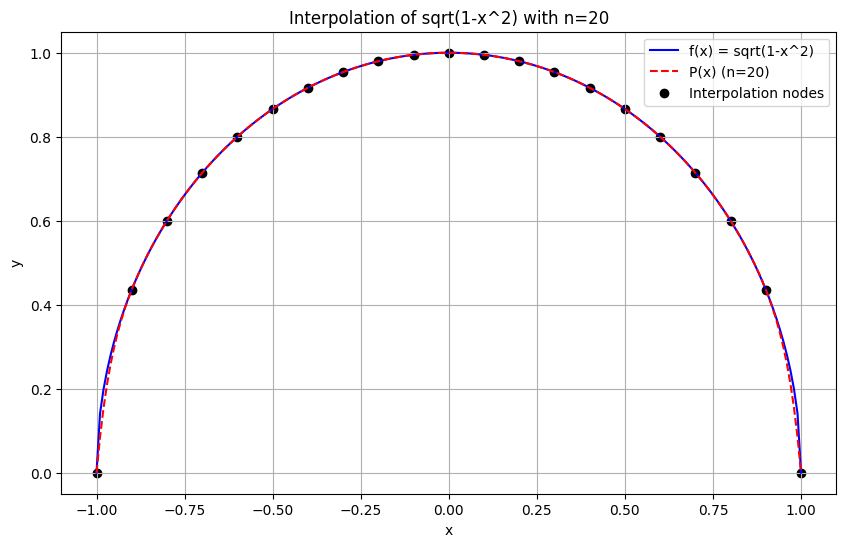

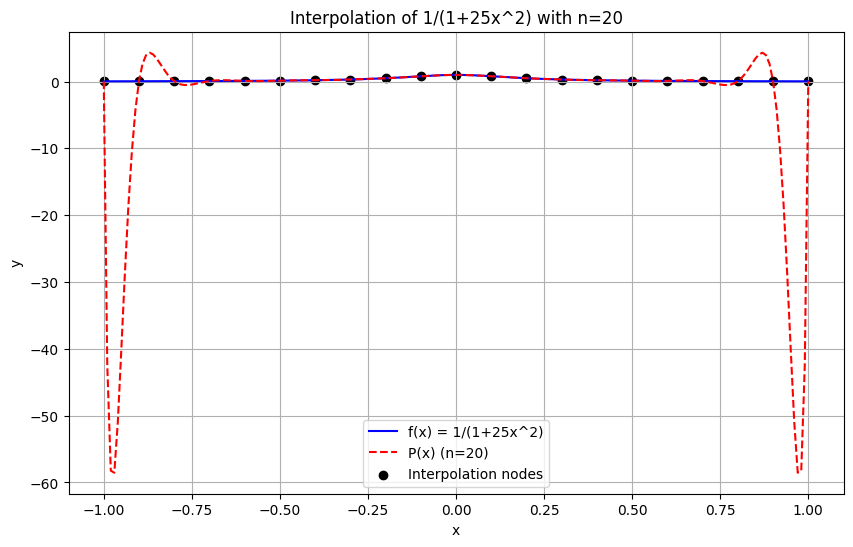

| n | f1 error | f2 error |
|---|----------|----------|
| 5 | 1.525e-01 | 4.327e-01 |
| 10 | 8.822e-02 | 1.916e+00 |
| 20 | 5.587e-02 | 5.859e+01 |
| 40 | 4.305e+06 | 3.018e+06 |



In [4]:
plot_interpolation(f1, 20, 'sqrt(1-x^2)')
plot_interpolation(f2, 20, '1/(1+25x^2)')
print(generate_error_table())

## 2
插值节点为切比雪夫节点(Chebyshev nodes)
$$
x_k = \cos\left(\frac{2k+1}{2(n+1)}\pi\right), \quad k = 0, 1, \dots, n,
$$

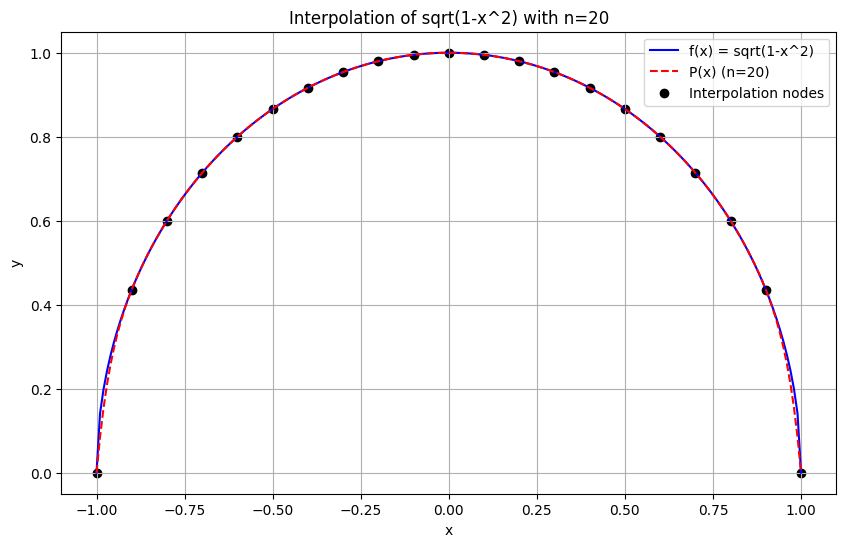

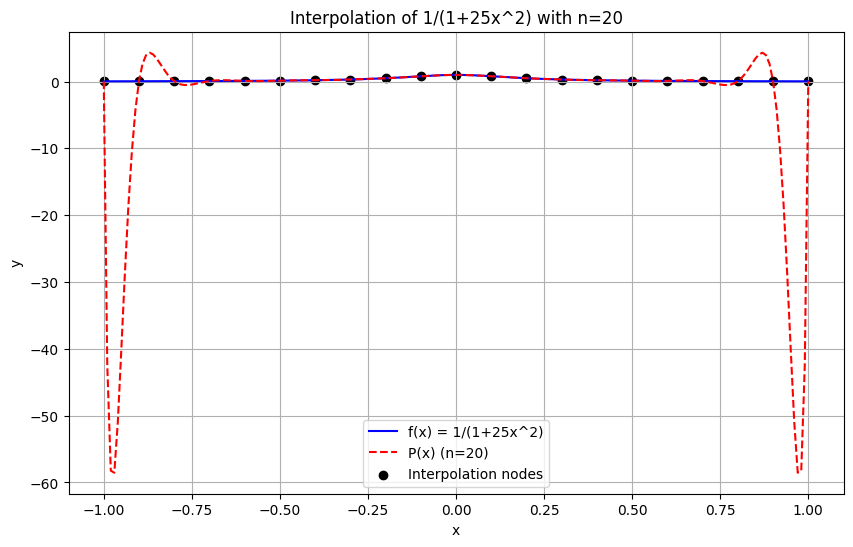

| n | f1 error | f2 error |
|---|----------|----------|
| 5 | 1.725e-01 | 5.559e-01 |
| 10 | 9.091e-02 | 1.089e-01 |
| 20 | 4.762e-02 | 1.533e-02 |
| 40 | 2.294e+03 | 1.206e+03 |



In [5]:
plot_interpolation(f1, 20, 'sqrt(1-x^2)', node_type='chebyshev')
plot_interpolation(f2, 20, '1/(1+25x^2)', node_type='chebyshev')
print(generate_error_table(node_type='chebyshev'))

## 3
对 $f(x) = \frac{1}{1+25x^2}$，实现 $n = 5, 10, 20$ 的Hermite插值，并输出误差值.

In [6]:
def f2_prime(x):
  return -50 * x / (1 + 25 * x**2)**2

def compute_hermite_interpolation(f, f_prime, n, N=200):
    x_nodes = np.linspace(-1, 1, n + 1)
    y_nodes = f(x_nodes)
    y_prime_nodes = f_prime(x_nodes)
    m = 2 * (n + 1)
    z_nodes = np.repeat(x_nodes, 2) # [x0, x0, x1, x1, ..., xn, xn]
    table = np.zeros((m, m))
    table[:, 0] = np.repeat(y_nodes, 2) # First column is [y0, y0, y1, y1, ...]
    for i in range(m - 1):
        if z_nodes[i+1] == z_nodes[i]:
            k = i // 2
            table[i, 1] = y_prime_nodes[k]
        else:
            table[i, 1] = (table[i+1, 0] - table[i, 0]) / (z_nodes[i+1] - z_nodes[i])

    for j in range(2, m):
        for i in range(m - j):
            denom = z_nodes[i+j] - z_nodes[i]
            table[i, j] = (table[i+1, j-1] - table[i, j-1]) / denom

    coeffs = table[0, :]

    x_eval = np.linspace(-1, 1, N + 1)
    y_interp = np.zeros_like(x_eval)
    for idx, x_val in enumerate(x_eval):
        term_prod = 1.0
        current_sum = coeffs[0]
        for k in range(1, m):
            term_prod *= (x_val - z_nodes[k-1])
            current_sum += coeffs[k] * term_prod
        y_interp[idx] = current_sum
    y_true = f(x_eval)
    error = np.max(np.abs(y_true - y_interp))
    return coeffs, x_eval, y_true, y_interp, error

In [7]:
def generate_hermite_error_table(N=200):

    n_values_hermite = [5, 10, 20]
    errors_hermite = []

    for n in n_values_hermite:
        _, _, _, _, error = compute_hermite_interpolation(f2, f2_prime, n, N)
        errors_hermite.append(error)
        if not np.isnan(error):
              print(f"n={n}, Max Error: {error:.3e}")

generate_hermite_error_table()

n=5, Max Error: 2.233e-01
n=10, Max Error: 3.836e+00
n=20, Max Error: 3.578e+03


## 4
对 $f(x) = \frac{1}{1+25x^2}$, 实现分片线性插值和分片Hermite多项式插值，并输出误差，此时随着n的增大误差变化趋势是怎样的？【分片线性插值或分片Hermite插值即为在每个区间 $[x_i, x_{i+1}]$ 上实现线性插值或Hermite插值，然后将函数拼接】

In [8]:
def piecewise_linear_interpolation(f, n, N=200):
    x_nodes = np.linspace(-1, 1, n + 1)
    y_nodes = f(x_nodes)
    x_eval = np.linspace(-1, 1, N + 1)
    y_true = f(x_eval)
    y_interp = np.interp(x_eval, x_nodes, y_nodes)
    error = np.max(np.abs(y_true - y_interp))
    return x_eval, y_true, y_interp, error

In [9]:
n_values = [5, 10, 20, 40, 80, 160, 320, 640, 1280, 2560, 5120, 10240, 20480]
errors_linear = []
for n_val in n_values:
    _, _, _, error_lin = piecewise_linear_interpolation(f2, n_val, N=200)
    errors_linear.append(error_lin)

# --- Output Table ---
print("\nError Table for Piecewise Interpolation of f(x) = 1 / (1 + 25x^2)")
table = "| n | Piecewise Linear Error  |\n"
table += "|---|------------------------|\n"
for i, n in enumerate(n_values):
    table += f"| {n:2d} | {errors_linear[i]:.3e}   |\n"

print(table)

for i in range(len(n_values) - 1):
    ratio = errors_linear[i] / errors_linear[i+1]
    print(f"  n={n_values[i]} to n={n_values[i+1]}: Ratio = {ratio:.2f}")


Error Table for Piecewise Interpolation of f(x) = 1 / (1 + 25x^2)
| n | Piecewise Linear Error  |
|---|------------------------|
|  5 | 5.000e-01   |
| 10 | 6.743e-02   |
| 20 | 4.154e-02   |
| 40 | 1.363e-02   |
| 80 | 3.660e-03   |
| 160 | 8.862e-04   |
| 320 | 2.311e-04   |
| 640 | 5.509e-05   |
| 1280 | 1.443e-05   |
| 2560 | 3.449e-06   |
| 5120 | 9.019e-07   |
| 10240 | 2.155e-07   |
| 20480 | 5.637e-08   |

  n=5 to n=10: Ratio = 7.41
  n=10 to n=20: Ratio = 1.62
  n=20 to n=40: Ratio = 3.05
  n=40 to n=80: Ratio = 3.72
  n=80 to n=160: Ratio = 4.13
  n=160 to n=320: Ratio = 3.83
  n=320 to n=640: Ratio = 4.20
  n=640 to n=1280: Ratio = 3.82
  n=1280 to n=2560: Ratio = 4.18
  n=2560 to n=5120: Ratio = 3.82
  n=5120 to n=10240: Ratio = 4.19
  n=10240 to n=20480: Ratio = 3.82


In [10]:
def piecewise_hermite_interpolation(f, f_prime, n, N=200):
    x_nodes = np.linspace(-1, 1, n + 1)
    y_nodes = f(x_nodes)
    y_prime_nodes = f_prime(x_nodes)
    x_eval = np.linspace(-1, 1, N + 1)
    y_true = f(x_eval)
    y_interp = np.zeros_like(x_eval)

    for k in range(n):
        x_k, x_kp1 = x_nodes[k], x_nodes[k+1]
        y_k, y_kp1 = y_nodes[k], y_nodes[k+1]
        yp_k, yp_kp1 = y_prime_nodes[k], y_prime_nodes[k+1]
        h = x_kp1 - x_k
        indices = np.where((x_eval >= x_k) & (x_eval <= x_kp1))[0]

        if len(indices) == 0:
            continue
        x_interval = x_eval[indices]
        t = (x_interval - x_k) / h

        h00 = 2*t**3 - 3*t**2 + 1
        h10 = t**3 - 2*t**2 + t
        h01 = -2*t**3 + 3*t**2
        h11 = t**3 - t**2

        y_interp[indices] = h00 * y_k + h10 * h * yp_k + h01 * y_kp1 + h11 * h * yp_kp1

    if N > 0 and n > 0:
      y_interp[-1] = y_nodes[-1]

    error = np.max(np.abs(y_true - y_interp))

    return x_eval, y_true, y_interp, error

In [11]:

errors_hermite = []

for n_val in n_values:
    _, _, _, error_her = piecewise_hermite_interpolation(f2, f2_prime, n_val, N=200)
    errors_hermite.append(error_her)

# --- Output Table ---
print("\nError Table for Piecewise Interpolation of f(x) = 1 / (1 + 25x^2)")
table = "| n  | Piecewise Hermite Error |\n"
table += "|---|-------------------------|\n"
for i, n in enumerate(n_values):
    table += f"| {n:2d} |{errors_hermite[i]:.3e}             |\n"

print(table)

for i in range(len(n_values) - 1):
    ratio = errors_linear[i] / errors_linear[i+1]
    print(f"  n={n_values[i]} to n={n_values[i+1]}: Ratio = {ratio:.2f} (Expected ~4)")


for i in range(len(n_values) - 1):
    ratio = errors_hermite[i] / errors_hermite[i+1]
    print(f"  n={n_values[i]} to n={n_values[i+1]}: Ratio = {ratio:.2f} (Expected ~16)")


Error Table for Piecewise Interpolation of f(x) = 1 / (1 + 25x^2)
| n  | Piecewise Hermite Error |
|---|-------------------------|
|  5 |2.500e-01             |
| 10 |1.293e-02             |
| 20 |1.250e-03             |
| 40 |1.751e-04             |
| 80 |1.322e-05             |
| 160 |7.635e-07             |
| 320 |5.307e-08             |
| 640 |2.929e-09             |
| 1280 |2.064e-10             |
| 2560 |1.150e-11             |
| 5120 |8.074e-13             |
| 10240 |4.496e-14             |
| 20480 |3.331e-15             |

  n=5 to n=10: Ratio = 7.41 (Expected ~4)
  n=10 to n=20: Ratio = 1.62 (Expected ~4)
  n=20 to n=40: Ratio = 3.05 (Expected ~4)
  n=40 to n=80: Ratio = 3.72 (Expected ~4)
  n=80 to n=160: Ratio = 4.13 (Expected ~4)
  n=160 to n=320: Ratio = 3.83 (Expected ~4)
  n=320 to n=640: Ratio = 4.20 (Expected ~4)
  n=640 to n=1280: Ratio = 3.82 (Expected ~4)
  n=1280 to n=2560: Ratio = 4.18 (Expected ~4)
  n=2560 to n=5120: Ratio = 3.82 (Expected ~4)
  n=5120 to n=102